In [64]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style for our charts later
sns.set_theme(style="whitegrid")

print("Libraries imported successfully!")

Libraries imported successfully!


In [65]:
import os
import pandas as pd

file_path = r"C:\Users\lenovo\OneDrive\Documents\5th sem RCF research project\Rainfall_Classification_Project\Data\Raw\Processed\gunupur_cleaned.csv"

df = pd.read_csv(file_path)

print("Actual columns in gunupur_cleaned.csv:")
print(df.columns.tolist())

Actual columns in gunupur_cleaned.csv:
['RH2M', 'T2MDEW', 'QV2M', 'T2MWET', 'PS', 'PSC', 'TS', 'T2M_MAX', 'T2M_MIN', 'ALLSKY_SFC_UV_INDEX', 'WS50M', 'WD50M', 'WSC', 'LATITUDE', 'LONGITUDE', 'Target_Rain']


In [66]:
# Cell 3: Data Types and Missing Values Overview
print("--- Dataset Information ---")
df.info()

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- Dataset Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   RH2M                 1827 non-null   int64  
 1   T2MDEW               1827 non-null   float64
 2   QV2M                 1827 non-null   float64
 3   T2MWET               1827 non-null   float64
 4   PS                   1827 non-null   float64
 5   PSC                  1827 non-null   float64
 6   TS                   1827 non-null   float64
 7   T2M_MAX              1827 non-null   float64
 8   T2M_MIN              1827 non-null   float64
 9   ALLSKY_SFC_UV_INDEX  1827 non-null   float64
 10  WS50M                1827 non-null   float64
 11  WD50M                1827 non-null   int64  
 12  WSC                  1827 non-null   float64
 13  LATITUDE             1827 non-null   float64
 14  LONGITUDE            1827 non-null   float64
 15  Target_Rai

In [67]:
# Cell 4: Check for Duplicate Records
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows in the dataset: {duplicates}")


Number of duplicate rows in the dataset: 0


In [68]:
# Cell 5: Remove duplicates
df = df.drop_duplicates()
print(f"Duplicates removed! New dataset shape: {df.shape}")

Duplicates removed! New dataset shape: (1827, 16)


C:\Users\lenovo\AppData\Local\Temp\ipykernel_10684\2778957575.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=target_col, palette='viridis')


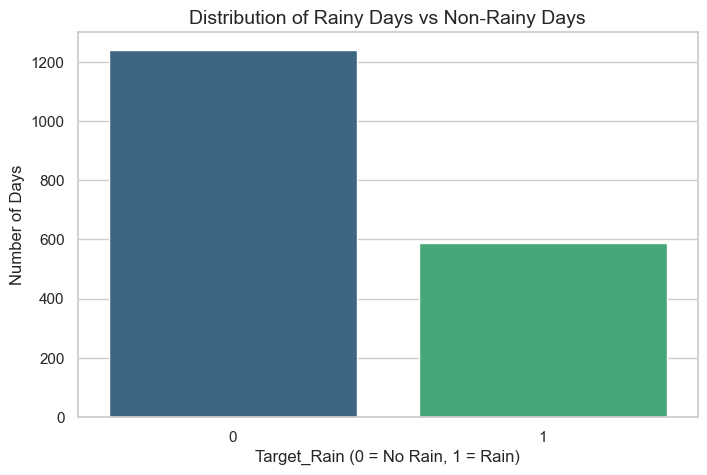

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identify which target column actually exists in your dataframe
target_col = 'Target_Rain' if 'Target_Rain' in df.columns else 'RainToday'

if target_col not in df.columns:
    print("❌ Available columns in df:", df.columns.tolist())
    raise KeyError(f"Neither 'Target_Rain' nor 'RainToday' was found in df. Check your column list above.")

# 2. Plot the distribution safely
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=target_col, palette='viridis')

plt.title('Distribution of Rainy Days vs Non-Rainy Days', fontsize=14)
plt.xlabel(f'{target_col} (0 = No Rain, 1 = Rain)', fontsize=12)
plt.ylabel('Number of Days', fontsize=12)

plt.show()

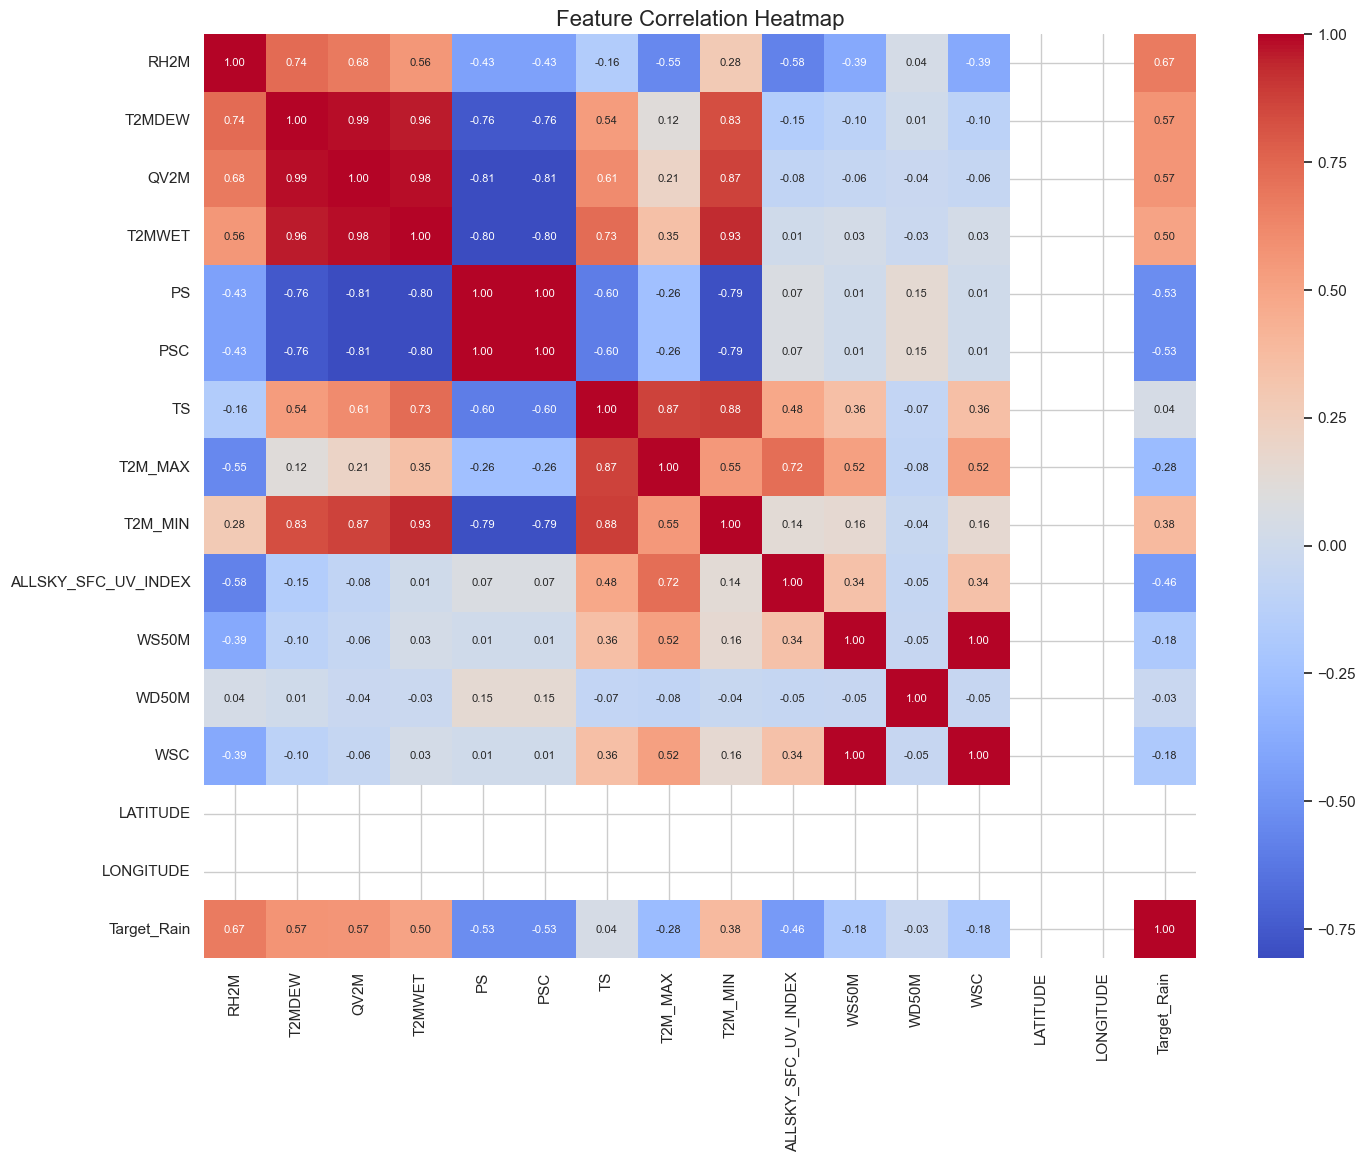

In [70]:
# Cell 7: Correlation Heatmap
plt.figure(figsize=(16, 12))

# We drop non-numeric columns (like 'DISTRICT') so the math works
numeric_df = df.select_dtypes(include=['float64', 'int64', 'int32'])
corr_matrix = numeric_df.corr()

# Generate the heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', cbar=True, annot_kws={"size": 8})
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.show()

C:\Users\lenovo\AppData\Local\Temp\ipykernel_10684\2585363318.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=target_col, y='QV2M', palette='Set2')


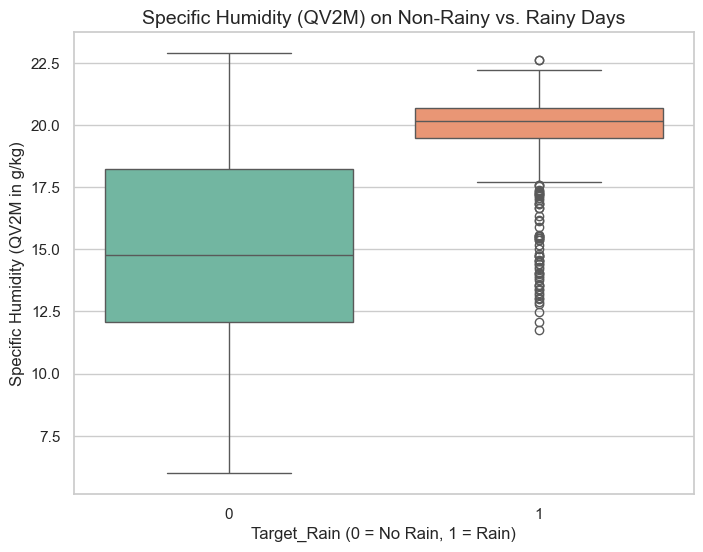

In [71]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dynamically resolve the correct target column name
target_col = 'Target_Rain' if 'Target_Rain' in df.columns else 'RainToday'

if target_col not in df.columns:
    raise KeyError(
        f"Neither 'Target_Rain' nor 'RainToday' exists in df. "
        f"Available columns are: {df.columns.tolist()}"
    )

# 2. Generate the boxplot safely
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x=target_col, y='QV2M', palette='Set2')

plt.title('Specific Humidity (QV2M) on Non-Rainy vs. Rainy Days', fontsize=14)
plt.xlabel(f'{target_col} (0 = No Rain, 1 = Rain)', fontsize=12)
plt.ylabel('Specific Humidity (QV2M in g/kg)', fontsize=12)

plt.show()

In [72]:
from sklearn.model_selection import train_test_split

# 1. Dynamically resolve the target column name
target_col = 'Target_Rain' if 'Target_Rain' in df.columns else 'RainToday'

if target_col not in df.columns:
    raise KeyError(f"❌ Target column not found! Available columns: {df.columns.tolist()}")

# 2. Isolate target variable y
y = df[target_col]

# 3. Drop target and any lingering metadata columns safely (ignoring already-removed columns)
cols_to_drop = [target_col, 'YEAR', 'MO', 'DY', 'DISTRICT', 'PRECTOTCORR']
X = df.drop(columns=cols_to_drop, errors='ignore')

# 4. Stratified 80/20 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("✅ Data Split Successful")
print(f"Training Features Shape: {X_train.shape}")
print(f"Testing Features Shape:  {X_test.shape}")
print(f"Target Distribution (Train):\n{y_train.value_counts(normalize=True).round(4)}")

✅ Data Split Successful
Training Features Shape: (1461, 15)
Testing Features Shape:  (366, 15)
Target Distribution (Train):
Target_Rain
0    0.6783
1    0.3217
Name: proportion, dtype: float64


In [73]:
print(X_test.iloc[0].tolist())

[70.0, 18.9, 14.13, 19.3, 1002.0, 1003.2, 26.8, 31.4, 20.7, 4.72, 17.01, 189.0, 4.41, 19.08, 83.81]


In [74]:
# Cell 10: Train the Random Forest Model
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize the model (using 50 trees to balance speed and accuracy)
rf_model = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

print("Training the model... (Please wait, this might take a minute!)")
rf_model.fit(X_train, y_train)

# Make predictions on the hidden test set
y_pred = rf_model.predict(X_test)

# Calculate and display the final accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"\n--- Model Evaluation ---")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Training the model... (Please wait, this might take a minute!)

--- Model Evaluation ---
Model Accuracy: 88.52%


--- Classification Report ---

              precision    recall  f1-score   support

           0       0.93      0.90      0.91       248
           1       0.81      0.85      0.83       118

    accuracy                           0.89       366
   macro avg       0.87      0.88      0.87       366
weighted avg       0.89      0.89      0.89       366



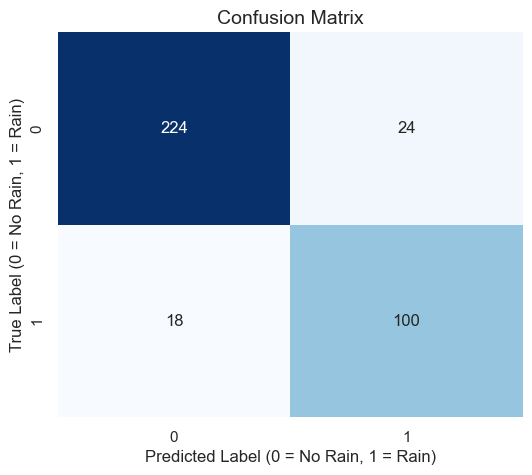

In [75]:
# Cell 11: Confusion Matrix and Classification Report
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Print the Classification Report
print("--- Classification Report ---\n")
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

# 2. Visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label (0 = No Rain, 1 = Rain)', fontsize=12)
plt.ylabel('True Label (0 = No Rain, 1 = Rain)', fontsize=12)
plt.show()

In [76]:
# Cell 12: Saving the trained AI model
import joblib

# Save the model to a file named 'weather_predictor.pkl'
joblib.dump(rf_model, 'weather_predictor.pkl')

print("Success! Your AI model has been saved as 'weather_predictor.pkl'")

Success! Your AI model has been saved as 'weather_predictor.pkl'


In [77]:
# This script searches your system's active RAM for any Random Forest models
found_models = []
for var_name, var_value in list(globals().items()):
    if 'RandomForestClassifier' in str(type(var_value)):
        found_models.append(var_name)

if found_models:
    print(f"SUCCESS: Your actual model variable name is: {found_models[0]}")
else:
    print("FATAL ERROR: No Random Forest model exists in memory. You have not run the training cells.")

SUCCESS: Your actual model variable name is: rf_model


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       248
           1       0.81      0.85      0.83       118

    accuracy                           0.89       366
   macro avg       0.87      0.88      0.87       366
weighted avg       0.89      0.89      0.89       366



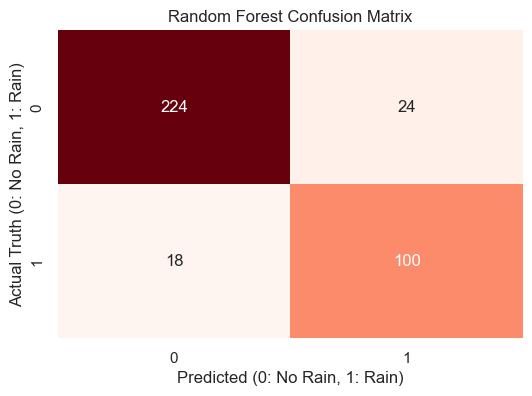

In [78]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Generate predictions for the entire test dataset
y_pred = rf_model.predict(X_test)

# 2. Print the macro statistical metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# 3. Generate and visualize the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.xlabel("Predicted (0: No Rain, 1: Rain)")
plt.ylabel("Actual Truth (0: No Rain, 1: Rain)")
plt.title("Random Forest Confusion Matrix")
plt.show()

In [79]:
# This script searches your system's active RAM for any Random Forest models
found_models = []
for var_name, var_value in globals().items():
    if 'RandomForestClassifier' in str(type(var_value)):
        found_models.append(var_name)

if found_models:
    print(f"SUCCESS: Your actual model variable name is: {found_models[0]}")
else:
    print("FATAL ERROR: No Random Forest model exists in memory. You have not run the training cells.")

SUCCESS: Your actual model variable name is: rf_model


In [80]:
import joblib
joblib.dump(rf_model, '../models/weather_predictor.pkl', compress=3)
print("Model successfully compressed and saved.")

Model successfully compressed and saved.
